In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
train = pd.read_csv('../data/raw/train.csv',
                    parse_dates=['Date'],
                    dtype={'StateHoliday': str},
                    low_memory=False)

In [4]:
store = pd.read_csv('../data/raw/store.csv')

In [5]:
print("Loaded:", train.shape, store.shape)

Loaded: (1017209, 9) (1115, 10)


In [6]:
store_clean = store.copy()

# 1. CompetitionDistance — 3 nulls

In [ ]:
store_clean['CompetitionDistance'] = store_clean['CompetitionDistance'].fillna(
    store_clean['CompetitionDistance'].median()
)

# 2. CompetitionOpenSince Month/Year — 354 nulls

In [ ]:
store_clean['CompetitionOpenSinceMonth'] = store_clean['CompetitionOpenSinceMonth'].fillna(0)
store_clean['CompetitionOpenSinceYear'] = store_clean['CompetitionOpenSinceYear'].fillna(0)


# 3. Promo2 related — 544 nulls

In [ ]:
store_clean['Promo2SinceWeek'] = store_clean['Promo2SinceWeek'].fillna(0)
store_clean['Promo2SinceYear'] = store_clean['Promo2SinceYear'].fillna(0)
store_clean['PromoInterval'] = store_clean['PromoInterval'].fillna('None')

# Verify — should all be 0 now

In [ ]:
print(store_clean.isnull().sum())

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


In [15]:
train_clean = train.copy()

# 1. Standardize StateHoliday

In [27]:
#    Raw has both integer 0 and string '0' — make all stringtrain_clean['StateHoliday'] = train_clean['StateHoliday'].astype(str)
train_clean['StateHoliday'] = train_clean['StateHoliday'].replace('0', 'none')
# Now values are: 'none', 'a' (public), 'b' (Easter), 'c' (Christmas)
print(train_clean['StateHoliday'].value_counts())

StateHoliday
none    986159
a        20260
b         6690
c         4100
Name: count, dtype: int64


# 2. Handle the 54 Open=1 but Sales=0 anomalies

In [ ]:
anomalies = train_clean[(train_clean['Open']==1) & (train_clean['Sales']==0)]
print("Anomaly rows:", len(anomalies))
# Decision: treat these as effectively closed — set Open to 0
train_clean.loc[(train_clean['Open']==1) & (train_clean['Sales']==0), 'Open'] = 0

Anomaly rows: 54


# 3. For modeling, we only care about open days

In [ ]:
#    Create a filtered version (keep original too)
train_open = train_clean[train_clean['Open'] == 1].copy()
print("Open days only:", len(train_open))

Open days only: 844338


In [19]:
import matplotlib.pyplot as plt

# IQR method on open days

In [ ]:
Q1 = train_open['Sales'].quantile(0.25)
Q3 = train_open['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [21]:
outliers = train_open[(train_open['Sales'] < lower) | (train_open['Sales'] > upper)]
print(f"Outliers: {len(outliers)} ({len(outliers)/len(train_open)*100:.2f}%)")
print(f"Sales range after IQR: {lower:.0f} to {upper:.0f}")

Outliers: 30769 (3.64%)
Sales range after IQR: -392 to 13612


# Visualize

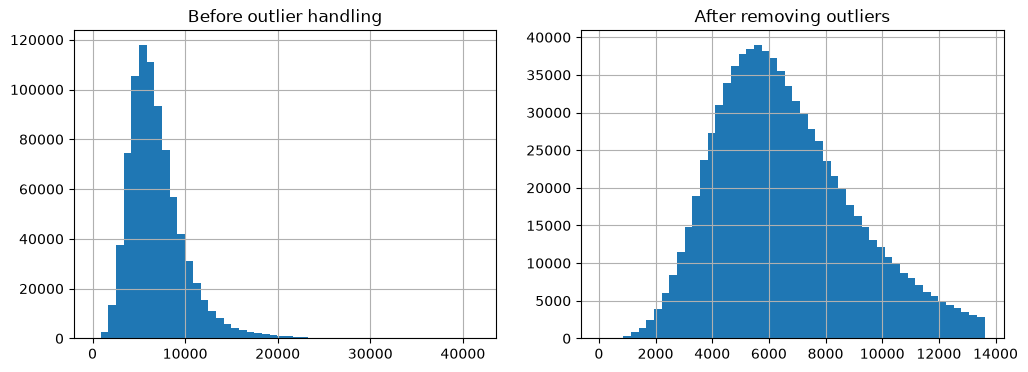

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_open['Sales'].hist(bins=50, ax=axes[0])
axes[0].set_title('Before outlier handling')
train_open[train_open['Sales'].between(lower, upper)]['Sales'].hist(bins=50, ax=axes[1])
axes[1].set_title('After removing outliers')
plt.savefig('../reports/outlier_comparison.png')
plt.show()

# Merge on Store ID

In [ ]:
df = train_open.merge(store_clean, on='Store', how='left')

In [24]:
print("Merged shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Any nulls after merge:", df.isnull().sum().sum())

Merged shape: (844338, 18)
Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
Any nulls after merge: 0


# Save to processed/

In [ ]:
df.to_csv('../data/processed/rossmann_cleaned.csv', index=False)
print("Saved to data/processed/rossmann_cleaned.csv")

Saved to data/processed/rossmann_cleaned.csv


In [26]:
print("Rows lost in merge:", 844338 - len(df))

Rows lost in merge: 0
